# Estudo de Caso: Modelagem de Custos de Saúde com Regressão Múltipla


Neste estudo, analisaremos os determinantes dos custos hospitalares individuais. O objetivo é prever o `custo` ($Y$) com base em três preditores: `idade`, `imc` (índice de massa corporal) e `score_risco` (uma métrica de saúde).

**Desafio Estatístico:** Custos de saúde são inerentemente positivos, apresentam variância crescente (heterocedasticidade) e assimetria à direita. Modelaremos o fenômeno via OLS, Gamma e Normal Inversa para determinar o melhor ajuste.

1. Geração de Dados e Análise Descritiva

In [14]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

def extrair_metricas(model, name):
    # Verificamos se o modelo possui os atributos de GLM
    # OLS não possui pearson_chi2, então usamos a variância dos resíduos como proxy ou NaN
    p_chi2 = getattr(model, 'pearson_chi2', np.nan)
    
    # Cálculo de Pseudo-R2 ou R2 tradicional
    # Se for OLS tem rsquared, se for GLM usamos uma aproximação por correlação
    if hasattr(model, 'rsquared'):
        r2 = model.rsquared
    else:
        # Proxy de R2 para GLM: correlação(obs, prev)^2
        y_obs = model.model.endog
        y_pred = model.predict()
        r2 = np.corrcoef(y_obs, y_pred)[0, 1]**2

    return {
        'Modelo': name,
        'AIC': model.aic,
        'Log-Likelihood': model.llf,
        'Pearson Chi2/DF': p_chi2 / model.df_resid if not np.isnan(p_chi2) else np.nan,
        'R² (ou Pseudo-R²)': r2
    }

In [15]:
df = pd.read_excel(r'C:\Users\Matheus\Desktop\Arquivos_PUC\Modelos de Regressão\Dados\dados_saude.xlsx')

Estatísticas Descritivas:
              custo        idade          imc  score_risco
count   1500.000000  1500.000000  1500.000000  1500.000000
mean    1279.665108    43.966568    29.009445    48.936630
std     1379.557523    15.288784     6.366264    28.517936
min       13.884029    18.240865    18.000256     0.003072
25%      440.633068    30.352284    23.662790    24.149959
50%      854.629545    44.341211    29.110026    48.754984
75%     1623.810935    57.190807    34.598103    72.925983
max    19439.214709    69.985319    39.963645    99.955770


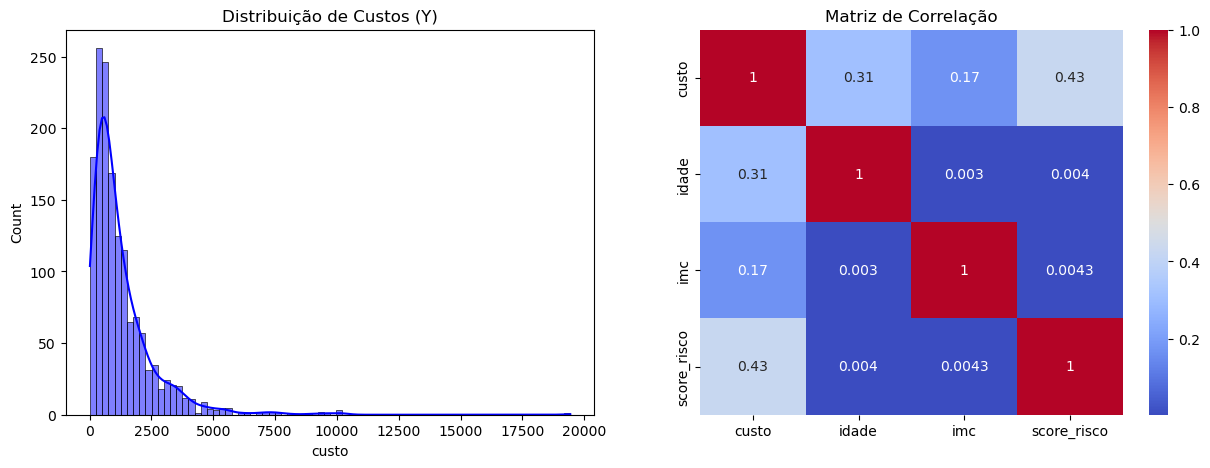

In [16]:
# --- ANÁLISE DESCRITIVA ---
print("Estatísticas Descritivas:")
print(df.describe())

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['custo'], kde=True, ax=ax[0], color='blue')
ax[0].set_title('Distribuição de Custos (Y)')
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Matriz de Correlação')
plt.show()

## 3. Divisão Treino/Teste e Validação de Suposições (Multicolinearidade)

### Teoria: Multicolinearidade (VIF)
Antes de modelar, verificamos a independência dos preditores através do **VIF (Variance Inflation Factor)**. 

Um VIF > 5 indica que a variância de um coeficiente está inflada devido à correlação com outros preditores, o que prejudica a interpretação estatística.

In [17]:
# Separação Treino e Teste (80/20)
train, test = train_test_split(df, test_size=0.2, random_state=42)

# Teste de Multicolinearidade (VIF)
X = train[['idade', 'imc', 'score_risco']]
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("\nTeste de VIF (Valores próximos a 1 indicam baixa colinearidade):")
print(vif_data)


Teste de VIF (Valores próximos a 1 indicam baixa colinearidade):
       Feature       VIF
0        idade  7.039346
1          imc  8.113354
2  score_risco  3.640228


### Teoria: OLS e Falha de Normalidade

O estimador OLS busca minimizar a soma dos quadrados dos resíduos. Para inferência válida, os resíduos devem ser independentes e seguir $N(0, \sigma^2)$. Em dados de custo, esperamos que o teste de Jarque-Bera rejeite a normalidade.

                            OLS Regression Results                            
Dep. Variable:                  custo   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.293
Method:                 Least Squares   F-statistic:                     166.5
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           3.64e-90
Time:                        21:29:40   Log-Likelihood:                -10172.
No. Observations:                1200   AIC:                         2.035e+04
Df Residuals:                    1196   BIC:                         2.037e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -1954.4849    191.367    -10.213      

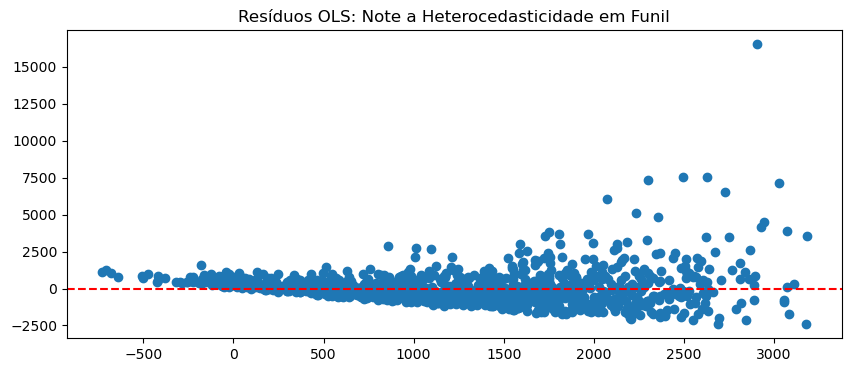

In [18]:
mod_ols = smf.ols('custo ~ idade + imc + score_risco', data=train).fit()
print(mod_ols.summary())

# Validação OLS: Independência e Normalidade
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(mod_ols.resid)
print(f"Estatística Durbin-Watson: {dw:.2f} (Próximo de 2 indica Independência)")

plt.figure(figsize=(10, 4))
plt.scatter(mod_ols.fittedvalues, mod_ols.resid)
plt.axhline(0, color='red', linestyle='--')
plt.title('Resíduos OLS: Note a Heterocedasticidade em Funil')
plt.show()

5. Modelos GLM: Gamma e Normal Inversa

### Teoria: GLM e Validação por Verossimilhança
Os GLMs estimam parâmetros via **Máxima Verossimilhança (MLE)**. 
- **Teste de Razão de Verossimilhança (Likelihood Ratio):** Compara se o modelo com preditores é superior ao modelo nulo.
- **Qui-Quadrado de Pearson:** Mede a discrepância entre valores observados e esperados. Se $Pearson / G.L. \approx 1$, não há evidência de superdispersão.

In [22]:
def validate_glm(model, label):
    print(f"\n--- Validação {label} ---")
    print(f"Log-Likelihood: {model.llf:.2f}")
    print(f"AIC: {model.aic:.2f}")
    
    # Pearson Chi-Square e Dispersão
    pearson_chi2 = model.pearson_chi2
    dispersion = pearson_chi2 / model.df_resid
    print(f"Pearson Chi-Square: {pearson_chi2:.2f}")
    print(f"Parâmetro de Dispersão Estimado: {dispersion:.2f}")

# Modelo 2: Gamma (Link Log)
mod_gamma = smf.glm('custo ~ idade + imc + score_risco', data=train, 
                    family=sm.families.Gamma(link=sm.families.links.log())).fit()

# Modelo 3: Normal Inversa (Link Log)
mod_ni = smf.glm('custo ~ idade + imc + score_risco', data=train, 
                 family=sm.families.InverseGaussian(link=sm.families.links.log())).fit()

validate_glm(mod_gamma, "GAMMA")
validate_glm(mod_ni, "NORMAL INVERSA")


--- Validação GAMMA ---
Log-Likelihood: -9427.64
AIC: 18863.27
Pearson Chi-Square: 595.46
Parâmetro de Dispersão Estimado: 0.50

--- Validação NORMAL INVERSA ---
Log-Likelihood: -9948.28
AIC: 19904.57
Pearson Chi-Square: 0.64
Parâmetro de Dispersão Estimado: 0.00


c:\Users\Matheus\miniconda3\envs\PUC\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\Matheus\miniconda3\envs\PUC\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


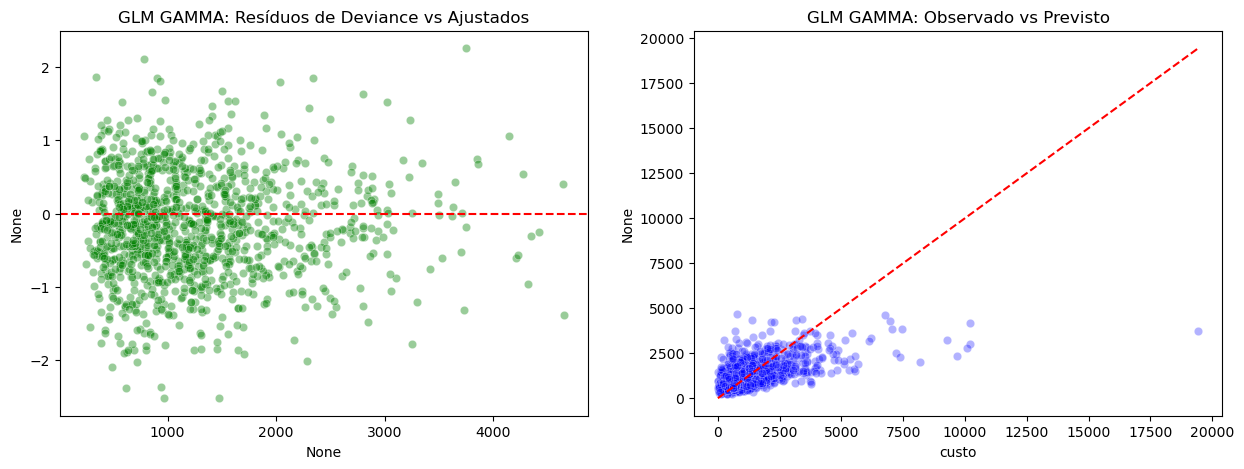

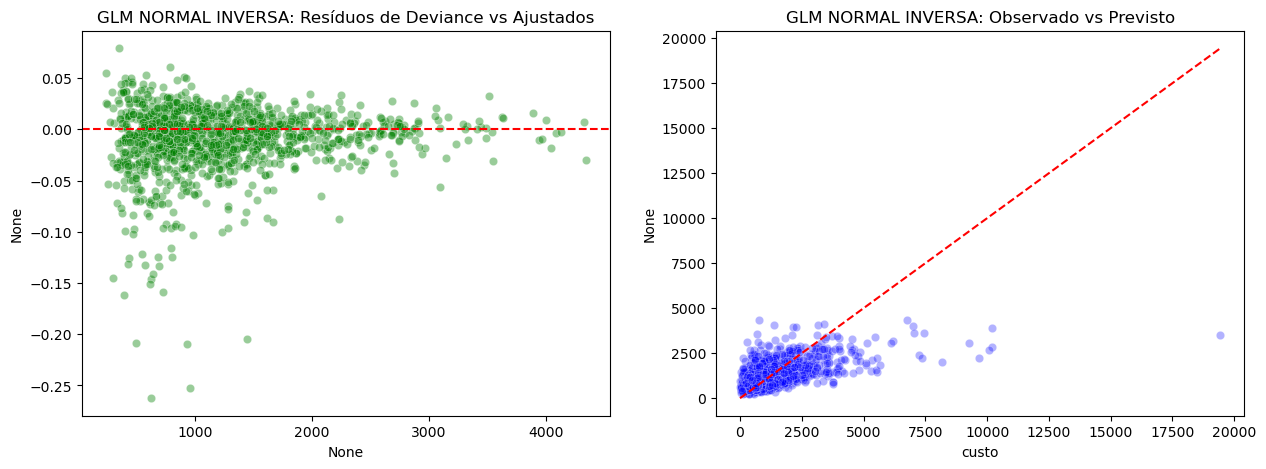

In [23]:
def plot_diagnosticos_glm(model, title):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    # Resíduos de Deviance vs Ajustados
    sns.scatterplot(x=model.fittedvalues, y=model.resid_deviance, ax=ax[0], color='green', alpha=0.4)
    ax[0].axhline(0, color='red', linestyle='--')
    ax[0].set_title(f'{title}: Resíduos de Deviance vs Ajustados')
    
    # Observado vs Previsto
    y_obs = train['custo']
    y_pred = model.predict(train)
    sns.scatterplot(x=y_obs, y=y_pred, ax=ax[1], color='blue', alpha=0.3)
    lims = [0, max(y_obs.max(), y_pred.max())]
    ax[1].plot(lims, lims, 'r--', label='Ideal')
    ax[1].set_title(f'{title}: Observado vs Previsto')
    plt.show()


plot_diagnosticos_glm(mod_gamma, "GLM GAMMA")
plot_diagnosticos_glm(mod_ni, "GLM NORMAL INVERSA")

In [24]:
# 2. Comparar Métricas
resumo = pd.DataFrame([
    extrair_metricas(mod_ols, "OLS"),
    extrair_metricas(mod_gamma, "Gamma"),
    extrair_metricas(mod_ni, "Normal Inversa")
])

print("\n--- COMPARATIVO DE PERFORMANCE ---")
print(resumo.sort_values('AIC'))


--- COMPARATIVO DE PERFORMANCE ---
           Modelo           AIC  Log-Likelihood  Pearson Chi2/DF  \
1           Gamma  18863.273541    -9427.636771         0.497876   
2  Normal Inversa  19904.565053    -9948.282527         0.000534   
0             OLS  20351.143561   -10171.571780              NaN   

   R² (ou Pseudo-R²)  
1           0.348875  
2           0.347528  
0           0.294546  
